## Домашнее задание 2. Реализация обучения диффузионной модели

###Цель домашнего занятия
Научиться реализовывать обучение диффузии под датасет и решить задачу Image Inpainting

### [6 баллов] Дообучение диффузионной модели.

В этом задании вам предстоит обучить диффузионную модель для решения задачи text-to-image. В предыдущем задании вы уже обучали диффузионную модель, но она была unconditional, то есть генерировала без каких-либо условий. В этот раз вам предлагается обучить свою text-to-image модель на датасете https://huggingface.co/datasets/Norod78/cartoon-blip-captions или на другом понравившемся датасете

---

В этой части задания вам рекомендуется взять код с семинара 4 и адаптировать его под обучение на новом датасете, с учетом того, что в нем содержаться картинки

**Ожидаемый результат.** В качестве результатов модели, от вас требуется предоставить визуализации генераций, полученных от вашей модели и код обучения модели, а также визуальное сравнение качества моделей до и после дообучения. Если не получится дообучить, то можно провести сравнение уже обученных адаптеров (3 балла).

In [8]:
import matplotlib.pyplot as plt
from datasets import load_dataset

train_dir = "/home/lev/project/ml-modern/homework/hw02/training"

In [ ]:
# !uv run huggingface-cli download --repo-type dataset "Norod78/cartoon-blip-captions"

Fetching 3 files:   0%|                                   | 0/3 [00:00<?, ?it/s]Downloading 'data/train-00000-of-00001-dfb0d9df7ebab67e.parquet' to '/home/lev/.cache/huggingface/hub/datasets--Norod78--cartoon-blip-captions/blobs/720a75399d52fff9657bea668b4b759a1a6dc87aa82f8f35a574d91b2b7e3bc8.incomplete'

README.md: 100%|███████████████████████████████| 536/536 [00:00<00:00, 2.16MB/s]
Download complete. Moving file to /home/lev/.cache/huggingface/hub/datasets--Norod78--cartoon-blip-captions/blobs/dea2d87be60204f3a64f4c743ab0787aa2eef673

(…)-00000-of-00001-dfb0d9df7ebab67e.parquet:   0%|   | 0.00/190M [00:00<?, ?B/s]Downloading '.gitattributes' to '/home/lev/.cache/huggingface/hub/datasets--Norod78--cartoon-blip-captions/blobs/7370acfb01ec70391e9e2389f65b95a5d5c87334.incomplete'

(…)-00000-of-00001-dfb0d9df7ebab67e.parquet:  11%| | 21.0M/190M [00:00<00:01, 15

.gitattributes: 2.22kB [00:00, 5.09MB/s]A
Download complete. Moving file to /home/lev/.cache/huggingface/hub/datasets--Norod78-

In [ ]:
# https://huggingface.co/datasets/Norod78/cartoon-blip-captions
# config.dataset_name = "Norod78/cartoon-blip-captions"
# name = "https://huggingface.co/datasets/Norod78/cartoon-blip-captions"
name = "Norod78/cartoon-blip-captions"
dataset = load_dataset(name, split="train")
print(dataset)

Generating train split:   0%|          | 0/3141 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'text'],
    num_rows: 3141
})


0: anime character, transparent and transparent
1: two people with a man's face
2: the avatar characters with two men, one in front of the image and one holding a stick
3: the south park character from south and america


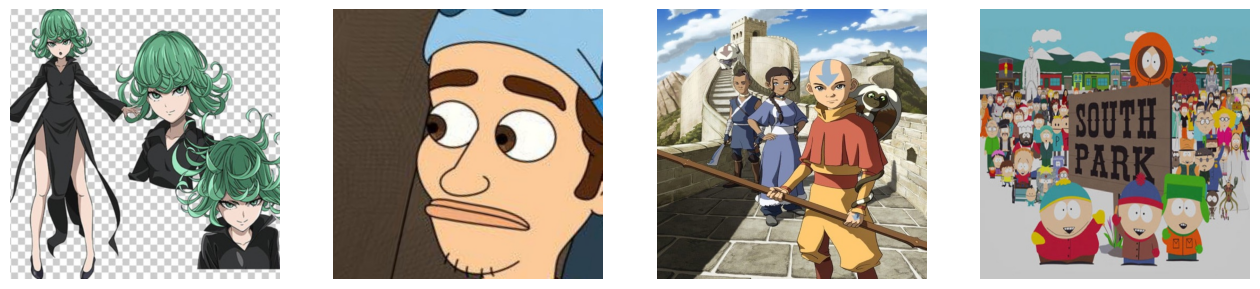

In [3]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for i, image in enumerate(dataset[:4]["image"]):
    axs[i].imshow(image)
    axs[i].set_axis_off()
fig.show()

for i, text in enumerate(dataset[:4]["text"]):
    print(f"{i}: {text}")

In [4]:
dataset[:4]["image"]

[<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=512x512>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=512x512>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=512x512>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=512x512>]

#### Установка kohya-ss/sd-scripts

1. Клонируем  kohya-ss/sd-scripts

```shell
lev@mild-fire-smells-fin-01:~/project/ml-modern/homework/hw02$ git clone https://github.com/kohya-ss/sd-scripts.git
Cloning into 'sd-scripts'...
remote: Enumerating objects: 10774, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 10774 (delta 28), reused 18 (delta 18), pack-reused 10725 (from 2)
Receiving objects: 100% (10774/10774), 12.54 MiB | 13.15 MiB/s, done.
Resolving deltas: 100% (7710/7710), done.
```

2. Установка venv

```shell
lev@mild-fire-smells-fin-01:~/project/ml-modern/homework/hw02$ uv init --python 3.10 --no-readme --no-package --no-description
Initialized project `hw02`
lev@mild-fire-smells-fin-01:~/project/ml-modern/homework/hw02$ uv venv --python 3.10 /home/lev/.cache/uv/virtualenvs/ml-modern-hw02
Using CPython 3.10.19
Creating virtual environment at: /home/lev/.cache/uv/virtualenvs/ml-modern-hw02
Activate with: source /home/lev/.cache/uv/virtualenvs/ml-modern-hw02/bin/activate
lev@mild-fire-smells-fin-01:~/project/ml-modern/homework/hw02$ ln -s /home/lev/.cache/uv/virtualenvs/ml-modern-hw02 .venv
lev@mild-fire-smells-fin-01:~/project/ml-modern/homework/hw02$ source /home/lev/.cache/uv/virtualenvs/ml-modern-hw02/bin/activate
```

3. Руками добавил requirements.txt в pyproject.toml

```shell
(ml-modern-hw02) lev@mild-fire-smells-fin-01:~/project/ml-modern/homework/hw02$ uv lock
Resolved 127 packages in 1.54s
(ml-modern-hw02) lev@mild-fire-smells-fin-01:~/project/ml-modern/homework/hw02$ uv sync
Resolved 127 packages in 2ms
Prepared 60 packages in 16.08s
Installed 118 packages in 4.28s
```

4. Установка library из kohya-ss/sd-scripts

Дописываем в pyproject.toml:
```toml
[tool.uv.sources]
library = { path = "/home/lev/mipt.project/ml-modern/homework/hw02/sd-scripts", editable = true }
```

```shell
(ml-modern-hw02) lev@mild-fire-smells-fin-01:~/project/ml-modern/homework/hw02$ uv lock
Resolved 124 packages in 518ms
Added library v0.0.0
(ml-modern-hw02) lev@mild-fire-smells-fin-01:~/project/ml-modern/homework/hw02$ uv sync
Resolved 124 packages in 2ms
Audited 119 packages in 3ms
```

- OS: Ubuntu 24.04.3 LTS (Linux)
- GPU: NVIDIA A100-SXM4-80GB
- System CUDA: 13.0
- uv: 0.9.5 installed

```shell
(ml-modern-hw02) lev@mild-fire-smells-fin-01:~/project/ml-modern/homework/hw02$ uv add xformers
Resolved 135 packages in 298ms
Prepared 4 packages in 20.86s
Uninstalled 3 packages in 456ms
Installed 4 packages in 354ms
 - nvidia-nccl-cu12==2.27.5
 + nvidia-nccl-cu12==2.27.3
 - torch==2.9.0
 + torch==2.8.0
 - triton==3.5.0
 + triton==3.4.0
 + xformers==0.0.32.post2
(ml-modern-hw02) lev@mild-fire-smells-fin-01:~/project/ml-modern/homework/hw02$ uv run python -m xformers.info
xFormers 0.0.32.post2
memory_efficient_attention.ckF:                    unavailable
memory_efficient_attention.ckB:                    unavailable
memory_efficient_attention.ck_splitKF:             unavailable
memory_efficient_attention.cutlassF-pt:            available
memory_efficient_attention.cutlassB-pt:            available
memory_efficient_attention.fa2F@2.5.7-pt:          available
memory_efficient_attention.fa2B@2.5.7-pt:          available
memory_efficient_attention.fa3F@2.8.0.post2-3-g3ba6f82: available
memory_efficient_attention.fa3B@2.8.0.post2-3-g3ba6f82: available
memory_efficient_attention.fa3F_splitKV@2.8.0.post2-3-g3ba6f82: available
memory_efficient_attention.triton_splitKF:         available
indexing.scaled_index_addF:                        available
indexing.scaled_index_addB:                        available
indexing.index_select:                             available
sp24.sparse24_sparsify_both_ways:                  available
sp24.sparse24_apply:                               available
sp24.sparse24_apply_dense_output:                  available
sp24._sparse24_gemm:                               available
sp24._cslt_sparse_mm_search@0.7.1:                 available
sp24._cslt_sparse_mm@0.7.1:                        available
swiglu.dual_gemm_silu:                             available
swiglu.gemm_fused_operand_sum:                     available
swiglu.fused.p.cpp:                                available
is_triton_available:                               True
pytorch.version:                                   2.8.0+cu128
pytorch.cuda:                                      available
gpu.compute_capability:                            8.0
gpu.name:                                          NVIDIA A100-SXM4-80GB
dcgm_profiler:                                     unavailable
build.info:                                        available
build.cuda_version:                                1208
build.hip_version:                                 None
build.python_version:                              3.9.23
build.torch_version:                               2.8.0+cu128
build.env.TORCH_CUDA_ARCH_LIST:                    7.5 8.0+PTX 9.0a
build.env.PYTORCH_ROCM_ARCH:                       None
build.env.XFORMERS_BUILD_TYPE:                     Release
build.env.XFORMERS_ENABLE_DEBUG_ASSERTIONS:        None
build.env.NVCC_FLAGS:                              -allow-unsupported-compiler
build.env.XFORMERS_PACKAGE_FROM:                   wheel-v0.0.32.post2
build.nvcc_version:                                12.8.93
source.privacy:                                    open source
```

Предыдущая ВМ сломалась, перестала быть доступной ТП не отвечает.

Переехал на другую ВМ:

```shell
lev@slim-book-opens-fin-02:~/project/ml-modern$ nvidia-smi  | grep -E 'Version|On'
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:04:00.0 Off |                  Off |

(ml-modern-hw02) lev@slim-book-opens-fin-02:~/project/ml-modern/homework/hw02$ uv run python -m xformers.info
xFormers 0.0.32.post2
memory_efficient_attention.ckF:                    unavailable
memory_efficient_attention.ckB:                    unavailable
memory_efficient_attention.ck_splitKF:             unavailable
memory_efficient_attention.cutlassF-pt:            available
memory_efficient_attention.cutlassB-pt:            available
memory_efficient_attention.fa2F@2.5.7-pt:          available
memory_efficient_attention.fa2B@2.5.7-pt:          available
memory_efficient_attention.fa3F@2.8.0.post2-3-g3ba6f82: available
memory_efficient_attention.fa3B@2.8.0.post2-3-g3ba6f82: available
memory_efficient_attention.fa3F_splitKV@2.8.0.post2-3-g3ba6f82: available
memory_efficient_attention.triton_splitKF:         available
indexing.scaled_index_addF:                        available
indexing.scaled_index_addB:                        available
indexing.index_select:                             available
sp24.sparse24_sparsify_both_ways:                  available
sp24.sparse24_apply:                               available
sp24.sparse24_apply_dense_output:                  available
sp24._sparse24_gemm:                               available
sp24._cslt_sparse_mm_search@0.7.1:                 available
sp24._cslt_sparse_mm@0.7.1:                        available
swiglu.dual_gemm_silu:                             available
swiglu.gemm_fused_operand_sum:                     available
swiglu.fused.p.cpp:                                available
is_triton_available:                               True
pytorch.version:                                   2.8.0+cu128
pytorch.cuda:                                      available
gpu.compute_capability:                            9.0
gpu.name:                                          NVIDIA H100 80GB HBM3
dcgm_profiler:                                     unavailable
build.info:                                        available
build.cuda_version:                                1208
build.hip_version:                                 None
build.python_version:                              3.9.23
build.torch_version:                               2.8.0+cu128
build.env.TORCH_CUDA_ARCH_LIST:                    7.5 8.0+PTX 9.0a
build.env.PYTORCH_ROCM_ARCH:                       None
build.env.XFORMERS_BUILD_TYPE:                     Release
build.env.XFORMERS_ENABLE_DEBUG_ASSERTIONS:        None
build.env.NVCC_FLAGS:                              -allow-unsupported-compiler
build.env.XFORMERS_PACKAGE_FROM:                   wheel-v0.0.32.post2
build.nvcc_version:                                12.8.93
source.privacy:                                    open source
```

##### pyproject.toml

```toml
[project]
name = "hw02"
version = "0.1.0"
requires-python = ">=3.10,<3.11"

dependencies = [
    "numpy<2.0",  # Required for opencv-python compatibility
    "accelerate==0.30.0",
    "transformers==4.44.0",
    "diffusers[torch]==0.25.0",
    "ftfy==6.1.1",
    # albumentations==1.3.0
    "opencv-python==4.8.1.78",
    "einops==0.7.0",
    "pytorch-lightning==1.9.0",
    "bitsandbytes>=0.46.0",
    "prodigyopt==1.0",
    "lion-pytorch==0.0.6",
    "tensorboard",
    "safetensors==0.4.2",
    # gradio==3.16.2
    "altair==4.2.2",
    "easygui==0.98.3",
    "toml==0.10.2",
    "voluptuous==0.13.1",
    "huggingface-hub==0.24.5",
    # for Image utils
    "imagesize==1.4.1",
    # for BLIP captioning
    # requests==2.28.2
    # timm==0.6.12
    # fairscale==0.4.13
    # for WD14 captioning (tensorflow)
    # tensorflow==2.10.1
    # for WD14 captioning (onnx)
    # onnx==1.15.0
    # onnxruntime-gpu==1.17.1
    # onnxruntime==1.17.1
    # for cuda 12.1(default 11.8)
    # onnxruntime-gpu --extra-index-url https://aiinfra.pkgs.visualstudio.com/PublicPackages/_packaging/onnxruntime-cuda-12/pypi/simple/
    # this is for onnx:
    # protobuf==3.20.3
    # open clip for SDXL
    # open-clip-torch==2.20.0
    # For logging
    "rich==13.7.0",
    "library",
    "datasets>=4.1.1",
    "matplotlib>=3.10.7",
    "xformers>=0.0.32.post2",
    "dotenv>=0.9.9",
    "torchvision>=0.23.0",
]

[tool.uv.sources]
library = { path = "/home/lev/mipt.project/ml-modern/homework/hw02/sd-scripts", editable = true }

[dependency-groups]
dev = [
    "ipykernel",
    "ipywidgets",
]
```

##### config.toml

```toml
[general]
shuffle_caption = true
caption_extension = '.txt'
keep_tokens = 1

[[datasets]]
resolution = 512
batch_size = 12             # Optimized for H100 80GB
enable_bucket = true
bucket_no_upscale = true
bucket_reso_steps = 64
min_bucket_reso = 256
max_bucket_reso = 1024

  [[datasets.subsets]]
  image_dir = '/home/lev/project/ml-modern/homework/hw02/training/data/1_cartoon character'
  class_tokens = 'cartoon character'
  num_repeats = 1
```

##### train_network_config.toml

```toml
# ===== Model and Paths =====
pretrained_model_name_or_path = "/home/lev/project/ml-modern/homework/hw02/training/pretrained_model/Anything-v3-1/Anything-v3-1.safetensors"
dataset_config = "/home/lev/project/ml-modern/homework/hw02/config.toml"
output_dir = "/home/lev/project/ml-modern/homework/hw02/training/output"
output_name = "cartoon_lora"
save_model_as = "safetensors"

# ===== Network Architecture =====
network_module = "networks.lora"
network_dim = 64
network_alpha = 64
network_dropout = 0

# ===== Training Parameters =====
max_train_steps = 2000          # ~6-8 epochs for 3141 images with batch_size=12
learning_rate = 1e-4
unet_lr = 1e-4
text_encoder_lr = 5e-5
lr_scheduler = "cosine"
lr_warmup_steps = 100

# ===== Optimizer =====
optimizer_type = "AdamW8bit"

# ===== Memory and Performance (H100 Optimized) =====
mixed_precision = "bf16"        # Better numerical stability on H100
xformers = true
cache_latents = true
gradient_checkpointing = true
gradient_accumulation_steps = 1

# ===== Saving =====
save_every_n_epochs = 1
save_precision = "fp16"
save_state = false

# ===== Logging =====
logging_dir = "/home/lev/project/ml-modern/homework/hw02/training/logs"
log_with = "tensorboard"

# ===== Data Loading =====
max_data_loader_n_workers = 12
persistent_data_loader_workers = true

# ===== Sample Generation =====
sample_every_n_epochs = 1       # Generate samples every epoch
sample_sampler = "euler_a"      # or "ddim", "k_euler", "k_dpm_2", etc.
sample_prompts = "/home/lev/project/ml-modern/homework/hw02/sample_prompts.txt"

# ===== Miscellaneous =====
seed = 42
prior_loss_weight = 1.0
noise_offset = 0.0
min_snr_gamma = 5.0  #           Improves training stability

# Basic wandb settings  
log_with = "wandb"  
wandb_run_name = "ml-modern-hw02-lora-cartoons"  
log_tracker_name = "custom_tracker_name"  
log_config = true  

```

sample_prompts.txt
```txt
cartoon character, rick with plazma gun
cartoon character, avatar flying on purple dragon
cartoon character, anime warrior with a big wide sword
```

##### train.sh

```shell
#!/bin/bash

set -e  # Exit on error

# Colors for output
GREEN='\033[0;32m'
YELLOW='\033[1;33m'
NC='\033[0m' # No Color

echo -e "${GREEN}========================================${NC}"
echo -e "${GREEN}LoRA Training Setup${NC}"
echo -e "${GREEN}========================================${NC}"

# Configuration
SCRIPT_DIR="/home/lev/project/ml-modern/homework/hw02"
SD_SCRIPTS_DIR="${SCRIPT_DIR}/sd-scripts"
CONFIG_FILE="${SCRIPT_DIR}/train_network_config.toml"
OUTPUT_DIR="${SCRIPT_DIR}/training/output"
LOGS_DIR="${SCRIPT_DIR}/training/logs"

# Create output directories if they don't exist
echo -e "${YELLOW}Creating output directories...${NC}"
mkdir -p "${OUTPUT_DIR}"
mkdir -p "${LOGS_DIR}"

# Verify paths exist
echo -e "${YELLOW}Verifying configuration...${NC}"

if [ ! -f "${CONFIG_FILE}" ]; then
    echo -e "ERROR: Config file not found at ${CONFIG_FILE}"
    exit 1
fi

if [ ! -d "${SD_SCRIPTS_DIR}" ]; then
    echo -e "ERROR: sd-scripts directory not found at ${SD_SCRIPTS_DIR}"
    exit 1
fi

# Check GPU availability
echo -e "${YELLOW}Checking GPU...${NC}"
nvidia-smi --query-gpu=name,memory.total --format=csv,noheader

# Navigate to sd-scripts directory
cd "${SD_SCRIPTS_DIR}"

# Launch training with accelerate
echo -e "${GREEN}========================================${NC}"
echo -e "${GREEN}Starting LoRA Training${NC}"
echo -e "${GREEN}========================================${NC}"
echo -e "Config: ${CONFIG_FILE}"
echo -e "Output: ${OUTPUT_DIR}"
echo -e "Logs: ${LOGS_DIR}"
echo -e "${GREEN}========================================${NC}"

accelerate launch \
    --num_cpu_threads_per_process=1 \
    --mixed_precision="bf16" \
    train_network.py \
    --config_file="${CONFIG_FILE}"

echo -e "${GREEN}========================================${NC}"
echo -e "${GREEN}Training completed!${NC}"
echo -e "${GREEN}========================================${NC}"
echo -e "Output models saved to: ${OUTPUT_DIR}"
echo -e "Logs saved to: ${LOGS_DIR}"
echo -e ""
echo -e "To view training logs:"
echo -e "  tensorboard --logdir=${LOGS_DIR}"
```

#### Готовим данные

In [7]:
import os

# train_data = dataset['train']

# Format: [repeats]_[triggerword] [class]
output_dir = "/home/lev/project/ml-modern/homework/hw02/training/data/1_cartoon character"
os.makedirs(output_dir, exist_ok=True)

# Export images with matching caption files
for idx, item in enumerate(dataset):
    # Save image
    image = item['image']
    image.save(f"{output_dir}/image_{idx:05d}.jpg")
    
    # Save caption as .txt file
    caption = item['text']  
    # Optional: add trigger word prefix
    caption_with_trigger = f"cartoon, {caption}"
    with open(f"{output_dir}/image_{idx:05d}.txt", 'w') as f:
        f.write(caption_with_trigger)

#### Скачиваем pre-trained модели

In [12]:
from dotenv import dotenv_values

models = {
    "Animefull-final-pruned": "https://huggingface.co/Linaqruf/personal-backup/resolve/main/models/animefull-final-pruned.ckpt",
    "Anything-v3-1": "https://huggingface.co/cag/anything-v3-1/resolve/main/anything-v3-1.safetensors",
    "AnyLoRA": "https://huggingface.co/Linaqruf/stolen/resolve/main/pruned-models/AnyLoRA_noVae_fp16-pruned.safetensors",
    "AnyLoRA-anime-mix": "https://huggingface.co/Lykon/AnyLoRA/resolve/main/AAM_Anylora_AnimeMix.safetensors",
    "AnimePastelDream": "https://huggingface.co/Lykon/AnimePastelDream/resolve/main/AnimePastelDream_Soft_noVae_fp16.safetensors",
    "Chillout-mix": "https://huggingface.co/Linaqruf/stolen/resolve/main/pruned-models/chillout_mix-pruned.safetensors",
    "OpenJourney-v4": "https://huggingface.co/prompthero/openjourney-v4/resolve/main/openjourney-v4.ckpt",
    "Stable-Diffusion-v1-5": "https://huggingface.co/Linaqruf/stolen/resolve/main/pruned-models/stable_diffusion_1_5-pruned.safetensors",
}

v2_models = {
    "stable-diffusion-2-1-base": "https://huggingface.co/stabilityai/stable-diffusion-2-1-base/resolve/main/v2-1_512-ema-pruned.safetensors",
    "stable-diffusion-2-1-768v": "https://huggingface.co/stabilityai/stable-diffusion-2-1/resolve/main/v2-1_768-ema-pruned.safetensors",
    "plat-diffusion-v1-3-1": "https://huggingface.co/p1atdev/pd-archive/resolve/main/plat-v1-3-1.safetensors",
    "replicant-v1": "https://huggingface.co/gsdf/Replicant-V1.0/resolve/main/Replicant-V1.0.safetensors",
    "illuminati-diffusion-v1-0": "https://huggingface.co/IlluminatiAI/Illuminati_Diffusion_v1.0/resolve/main/illuminati_diffusion_v1.0.safetensors",
    "illuminati-diffusion-v1-1": "https://huggingface.co/4eJIoBek/Illuminati-Diffusion-v1-1/resolve/main/illuminatiDiffusionV1_v11.safetensors",
    "waifu-diffusion-1-4-anime-e2": "https://huggingface.co/hakurei/waifu-diffusion-v1-4/resolve/main/wd-1-4-anime_e2.ckpt",
    "waifu-diffusion-1-5-e2": "https://huggingface.co/waifu-diffusion/wd-1-5-beta2/resolve/main/checkpoints/wd-1-5-beta2-fp32.safetensors",
    "waifu-diffusion-1-5-e2-aesthetic": "https://huggingface.co/waifu-diffusion/wd-1-5-beta2/resolve/main/checkpoints/wd-1-5-beta2-aesthetic-fp32.safetensors",
}

model_name = "Anything-v3-1"
# model_name = "Stable-Diffusion-v1-5"
model_url = models.get(model_name)

pretrained_model = os.path.join(train_dir, "pretrained_model", model_name)

def install(checkpoint_name, url):
    ext = "ckpt" if url.endswith(".ckpt") else "safetensors"

    hf_token = dotenv_values().get("HF_TOKEN")
    user_header = f'"Authorization: Bearer {hf_token}"'

    !aria2c --console-log-level=error --summary-interval=10 \
        --header={user_header} \
        -c -x 16 -k 1M -s 16 \
        -d {pretrained_model} \
        -o {checkpoint_name}.{ext} "{url}"

install(model_name, model_url)


Download Results:
gid   |stat|avg speed  |path/URI
======+====+===========+=======================================================
925163|OK  |       0B/s|/home/lev/project/ml-modern/homework/hw02/training/pretrained_model/Anything-v3-1/Anything-v3-1.safetensors

Status Legend:
(OK):download completed.


#### Запуск обучения 1.

```shell
(ml-modern-hw02) lev@slim-book-opens-fin-02:~/project/ml-modern/homework/hw02$ ./train.sh                                                                     
========================================                                                                                                                      
LoRA Training Setup                                                                                                                                           
========================================                                                                                                                      
Creating output directories...                                                                                                                                
Verifying configuration...                                                                                                                                    
Checking GPU...                                                                                                                                               
NVIDIA H100 80GB HBM3, 81559 MiB                                               
========================================
Starting LoRA Training                                                         
========================================                                                                                                                      
Config: /home/lev/project/ml-modern/homework/hw02/train_network_config.toml
Output: /home/lev/project/ml-modern/homework/hw02/training/output
Logs: /home/lev/project/ml-modern/homework/hw02/training/logs
========================================                                      
/home/lev/project/ml-modern/homework/hw02/.venv/lib/python3.10/site-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytr
ee_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
2025-11-04 03:31:49 INFO     Loading settings from /home/lev/project/ml-modern/homework/hw02/train_network_config.toml...                   train_util.py:4015
                    INFO     /home/lev/project/ml-modern/homework/hw02/train_network_config                                                 train_util.py:4034
2025-11-04 03:31:49 INFO     prepare tokenizer                                                                                              train_util.py:4561
/home/lev/project/ml-modern/homework/hw02/.venv/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenizati
on_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default
. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
                    INFO     Loading dataset config from /home/lev/project/ml-modern/homework/hw02/config.toml                            train_network.py:161
                    INFO     prepare images.                                                                                                train_util.py:1689
                    INFO     found directory /home/lev/project/ml-modern/homework/hw02/training/data/1_cartoon character contains 3141      train_util.py:1636
                             image files                                                                                                                      
                    INFO     3141 train images with repeating.                                                                              train_util.py:1730
                    INFO     0 reg images.                                                                                                  train_util.py:1733
                    WARNING  no regularization images / 正則化画像が見つかりませんでした                                                    train_util.py:1738
                    INFO     [Dataset 0]                                                                                                    config_util.py:572
                               batch_size: 12                                                                                                                 
                               resolution: (512, 512)                                                                                                         
...
...
...
2025-11-04 03:49:42 INFO     prompt: cartoon character, anime warrior with a big wide sword                                                 train_util.py:5614
                    INFO     negative_prompt: None                                                                                          train_util.py:5615
                    INFO     height: 512                                                                                                    train_util.py:5616
                    INFO     width: 512                                                                                                     train_util.py:5617
                    INFO     sample_steps: 30                                                                                               train_util.py:5618
                    INFO     scale: 7.5                                                                                                     train_util.py:5619
                    INFO     sample_sampler: euler_a                                                                                        train_util.py:5620
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:01<00:00, 21.44it/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:01<00:00, 21.50it/s]
saving checkpoint: /home/lev/project/ml-modern/homework/hw02/training/output/cartoon_lora.safetensors
2025-11-04 03:49:44 INFO     model saved.                                                                                                train_network.py:1112
steps: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [11:36<00:00,  2.87it/s, avr_loss=0.099]
========================================
Training completed!
========================================
Output models saved to: /home/lev/project/ml-modern/homework/hw02/training/output
Logs saved to: /home/lev/project/ml-modern/homework/hw02/training/logs

To view training logs:
  tensorboard --logdir=/home/lev/project/ml-modern/homework/hw02/training/logs
(ml-modern-hw02) lev@slim-book-opens-fin-02:~/project/ml-modern/homework/hw02$ 
```
![alt text](tensorboard-01.png)

#### Визуализация


In [3]:
import os

outdir = "/home/lev/project/ml-modern/homework/hw02/training/output/generation"
pretrained_model_file = "/home/lev/project/ml-modern/homework/hw02/training/pretrained_model/Anything-v3-1/Anything-v3-1.safetensors"
model_dir = "/home/lev/project/ml-modern/homework/hw02/training/output"

def generate_images(model_epoch):
    if model_epoch == -1:
        model_file = os.path.join(model_dir, f"cartoon_lora.safetensors")
        model_outdir = os.path.join(outdir, "latest")
    else:
        model_file = os.path.join(model_dir, f"cartoon_lora-{model_epoch:06d}.safetensors")
        model_outdir = os.path.join(outdir, f"{model_epoch}")

    print(f"Generating images for model {model_file}")
    print(f"Output directory: {model_outdir}")

    !uv run python sd-scripts/gen_img_diffusers.py \
        --ckpt {pretrained_model_file} \
        --network_module networks.lora \
    --network_weights {model_file} \
    --outdir {model_outdir} \
    --xformers --fp16 --W 512 --H 512 --steps 30 --scale 7.5 \
    --from_file prompts.txt \
    --images_per_prompt 3 \
    --batch_size 4 \
    --n_iter 1 \
    --sequential_file_name

In [ ]:
generate_images(5)

Generating images for model /home/lev/project/ml-modern/homework/hw02/training/output/cartoon_lora-000005.safetensors
Output directory: /home/lev/project/ml-modern/homework/hw02/training/output/generation/5
/home/lev/project/ml-modern/homework/hw02/.venv/lib/python3.10/site-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
2025-11-04 09:46:40 INFO     load StableDiffusion      ]8;id=738773;file:///home/lev/project/ml-modern/homework/hw02/sd-scripts/gen_img_diffusers.py\gen_img_diffusers.py]8;;\:]8;id=386097;file:///home/lev/project/ml-modern/homework/hw02/sd-scripts/gen_img_diffusers.py#2230\2230]8;;\
                             checkpoint                                         
                    INFO     UNet2DConditionModel: 64, 8,  ]8;id=261018;file:///home/lev/project/ml-modern/homework/hw02/sd-scrip

In [4]:
generate_images(-1)

Generating images for model /home/lev/project/ml-modern/homework/hw02/training/output/cartoon_lora.safetensors
Output directory: /home/lev/project/ml-modern/homework/hw02/training/output/generation/latest


/home/lev/project/ml-modern/homework/hw02/.venv/lib/python3.10/site-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
2025-11-04 10:11:30 INFO     load StableDiffusion      ]8;id=717941;file:///home/lev/project/ml-modern/homework/hw02/sd-scripts/gen_img_diffusers.py\gen_img_diffusers.py]8;;\:]8;id=596195;file:///home/lev/project/ml-modern/homework/hw02/sd-scripts/gen_img_diffusers.py#2230\2230]8;;\
                             checkpoint                                         
2025-11-04 10:11:36 INFO     UNet2DConditionModel: 64, 8,  ]8;id=758403;file:///home/lev/project/ml-modern/homework/hw02/sd-scripts/library/original_unet.py\original_unet.py]8;;\:]8;id=42019;file:///home/lev/project/ml-modern/homework/hw02/sd-scripts/library/original_unet.py#1387\1387]8;;\
                             768, Fals

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
import glob
import os

def visualize_images(model_epoch):
    print(f"Checkpoint: {model_epoch}")
    if model_epoch == -1:
        model_outdir = os.path.join(outdir, "latest")
    else:
        model_outdir = os.path.join(outdir, f"{model_epoch}")

    png_files = sorted(glob.glob(os.path.join(model_outdir, "*.png")))
    n = len(png_files)
    print(f"Found {n} images")

    with open('prompts.txt', 'r') as f:
        print(f.read())

    # Calculate grid dimensions (6 images per row)
    cols = 6
    rows = (n + cols - 1) // cols  # Ceiling division

    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 3.5))
    # Handle case when axes is 1D or single element
    if n == 1:
        axes = [axes]
    elif rows == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx, img_path in enumerate(png_files):
        img = Image.open(img_path)
        axes[idx].imshow(img)
        axes[idx].set_title(os.path.basename(img_path), fontsize=8)
        axes[idx].axis('off')

    # Hide empty subplots
    for idx in range(n, rows * cols):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

Checkpoint: 5
Found 12 images
cartoon character, rick using portalgun
cartoon character, avatar on a ship in a sea
cartoon character, girl talking to a horse
cartoon character, anime warriors eating pizza in a desert



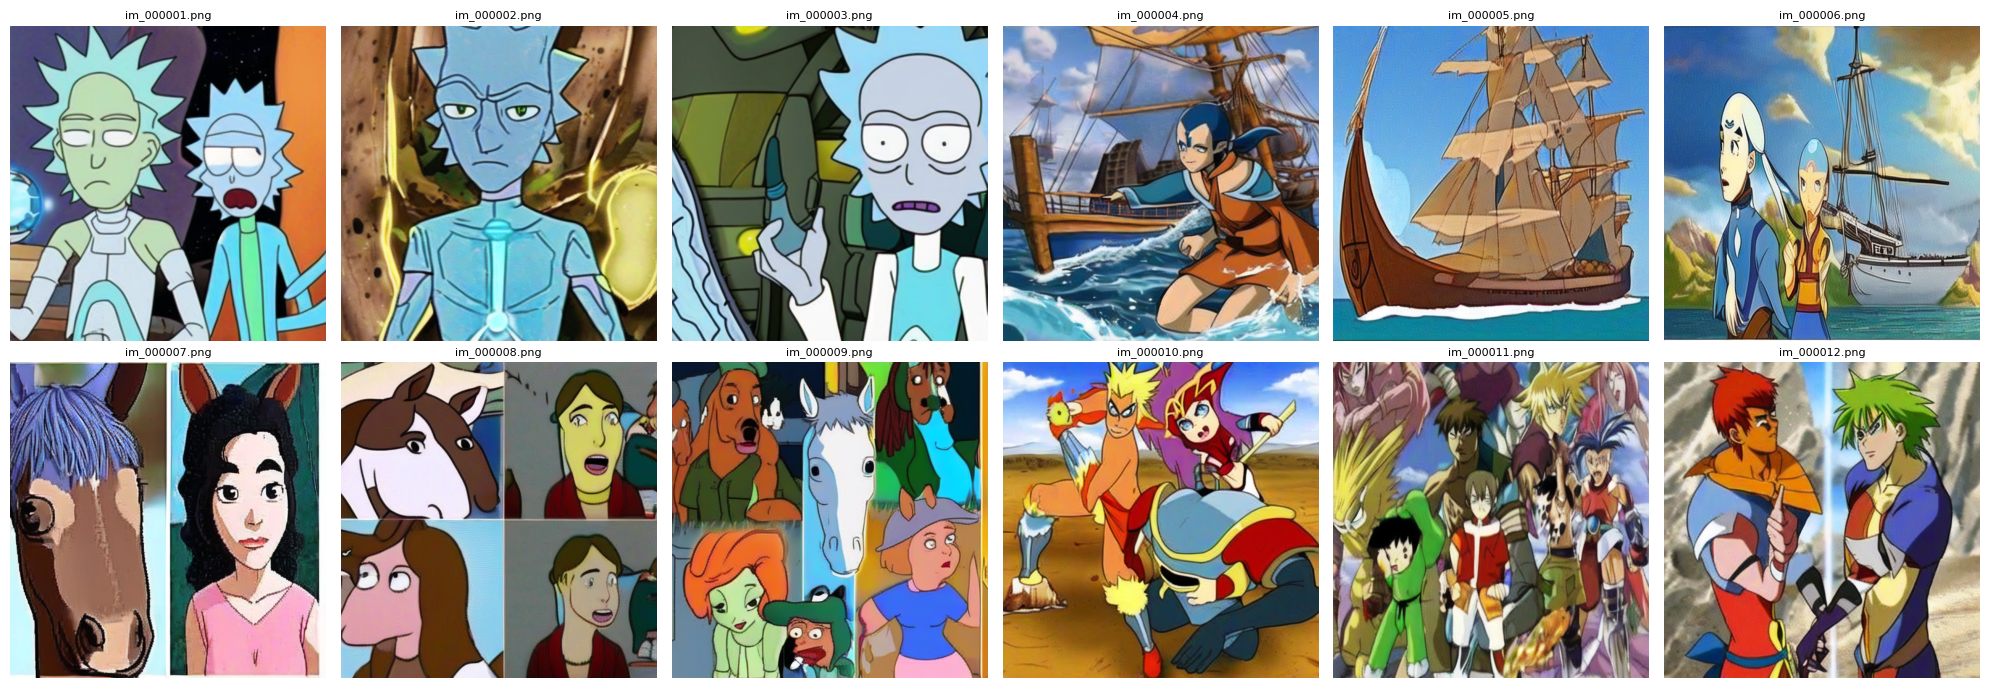

Checkpoint: -1
Found 12 images
cartoon character, rick using portalgun
cartoon character, avatar on a ship in a sea
cartoon character, girl talking to a horse
cartoon character, anime warriors eating pizza in a desert



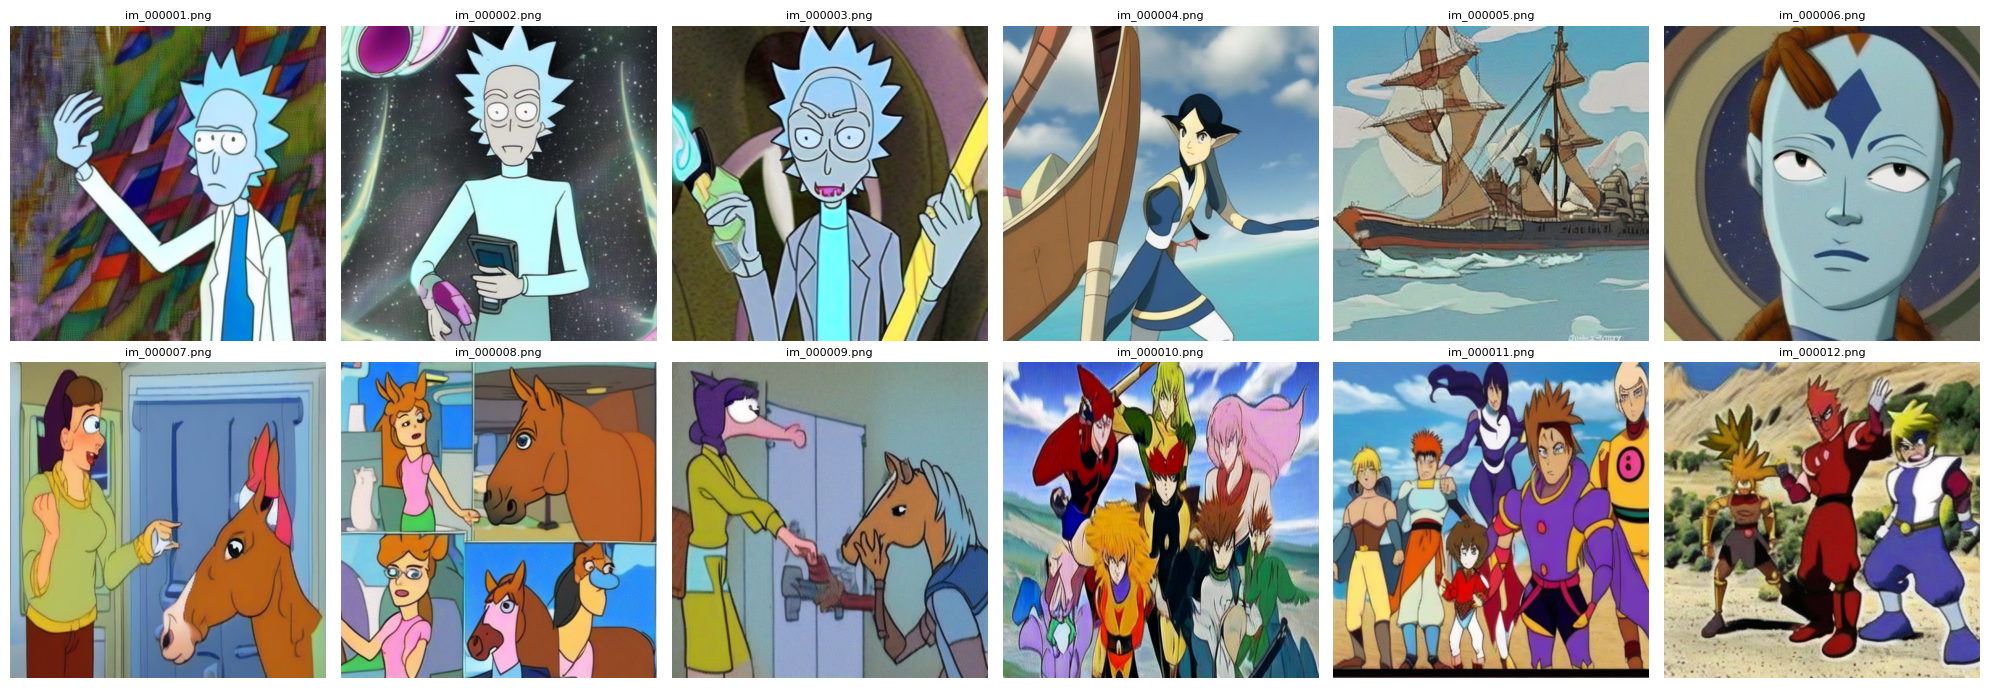

In [7]:
#Визулизации

visualize_images(5)
visualize_images(-1)


#### Выводы и т. п.

Попытка 1.

Пробовал запустить ноутбук из семинара 4. Видимо он запускался в старом колабе с питоном 3.10.
Сейчас у колаба питон 3.12 и 3.11. 
Пытался порешить проблемы с зависимостями. Использовал uv, локальный 
Linux Ubuntu 24.04с 1 x RTX 3080 10GB.
Так и не получилось. Сам использованный kohya-trainer deprecated и в архиве.

Попытка 2.

Пробую актульную версию [kohya-ss/sd-scripts](https://github.com/kohya-ss/sd-scripts) на Linux Ubuntu 24.04 с 1 x NVIDIA A100-SXM4-80GB.




### [4 балла] Image Inpainting
В первой части задания (2 балла) вам предстоит обучить диффузионную модель решать задачу image inpainting. Для этого вам необходимо модифицировать код из семинара 2 следующий образом:
- Реализовать функцию генерации маски, можно использовать приведенную ниже или реализовать свою.
- Добавить в UNet новых 4 канала, куда подавать замаскированное изображение и маску.
- Запустить обучение.

---

**Ожидаемый результат.** В качестве результатов модели, от вас требуется предоставить визуализации генераций, полученных от вашей модели и код обучения модели.

In [ ]:
import numpy as np

class RectangleGenerator:
    """
    Generates for each object a mask where unobserved region is
    a rectangle which square divided by the image square is in
    interval [min_rect_rel_square, max_rect_rel_square].
    """
    def __init__(self, min_rect_rel_square=0.3, max_rect_rel_square=1):
        self.min_rect_rel_square = min_rect_rel_square
        self.max_rect_rel_square = max_rect_rel_square

    def gen_coordinates(self, width, height):
        x1, x2 = np.random.randint(0, width, 2)
        y1, y2 = np.random.randint(0, height, 2)
        x1, x2 = min(x1, x2), max(x1, x2)
        y1, y2 = min(y1, y2), max(y1, y2)
        return int(x1), int(y1), int(x2), int(y2)

    def __call__(self, batch):
        batch_size, num_channels, width, height = batch.shape
        mask = torch.zeros_like(batch)
        for i in range(batch_size):
            x1, y1, x2, y2 = self.gen_coordinates(width, height)
            sqr = width * height
            while not (self.min_rect_rel_square * sqr <=
                       (x2 - x1 + 1) * (y2 - y1 + 1) <=
                       self.max_rect_rel_square * sqr):
                x1, y1, x2, y2 = self.gen_coordinates(width, height)
            mask[i, :, x1: x2 + 1, y1: y2 + 1] = 1
        return mask

Во второй части задания (2 балла) вам предстоит провизуализировать результаты полученной модели inpainting и модели SD через [демо](https://colab.research.google.com/github/huggingface/notebooks/blob/main/diffusers/in_painting_with_stable_diffusion_using_diffusers.ipynb#scrollTo=R596bpT2ynqV). Пример демо реализован ниже. Если у вас не получится реализовать модель из первого задания, то вы можете использовать модель SD и получите один балл

**Ожидаемый результат.** От вас ожидается анализ кейсов, когда модель отрабатывает хорошо (например, определенный тип масок), а когда плохо.

In [ ]:
# Визуализации